# Training YOLO with Label Studio Data

This notebook trains a YOLO model using data labeled with Label Studio, ensuring compatibility with the existing detection system.

## 1. Setup and Imports

In [1]:
import os
import json
import shutil
import cv2
import numpy as np
import yaml
from pathlib import Path
from typing import Dict, List, Tuple
import matplotlib.pyplot as plt

# Import existing components for compatibility
from abbvisionsystem.training_pipeline.yolo_trainer import YOLODefectDetector
from abbvisionsystem.models.yolo_model import YOLODefectModel

print("🚀 Setting up Label Studio YOLO Training")
print("📊 This notebook will train a YOLO model compatible with your existing detection system")

🚀 Setting up Label Studio YOLO Training
📊 This notebook will train a YOLO model compatible with your existing detection system


## 2. Label Studio Data Analysis

In [2]:
# Define paths
LABELSTUDIO_DATA_DIR = "data/chocopie_label_studio"
IMAGES_DIR = os.path.join(LABELSTUDIO_DATA_DIR, "images")
LABELS_DIR = os.path.join(LABELSTUDIO_DATA_DIR, "labels")
CLASSES_FILE = os.path.join(LABELSTUDIO_DATA_DIR, "classes.txt")
NOTES_FILE = os.path.join(LABELSTUDIO_DATA_DIR, "notes.json")

# Output directory for processed dataset
OUTPUT_DATASET_DIR = "training_data/labelstudio_yolo_dataset"

print(f"📁 Label Studio Data Directory: {LABELSTUDIO_DATA_DIR}")
print(f"🖼️  Images Directory: {IMAGES_DIR}")
print(f"🏷️  Labels Directory: {LABELS_DIR}")
print(f"📝 Classes File: {CLASSES_FILE}")
print(f"📋 Notes File: {NOTES_FILE}")
print(f"📤 Output Dataset: {OUTPUT_DATASET_DIR}")

📁 Label Studio Data Directory: data/chocopie_label_studio
🖼️  Images Directory: data/chocopie_label_studio/images
🏷️  Labels Directory: data/chocopie_label_studio/labels
📝 Classes File: data/chocopie_label_studio/classes.txt
📋 Notes File: data/chocopie_label_studio/notes.json
📤 Output Dataset: training_data/labelstudio_yolo_dataset


In [3]:
def analyze_labelstudio_data():
    """Analyze the Label Studio dataset structure and contents."""
    print("🔍 Analyzing Label Studio Dataset...")
    
    # Check directory structure
    if not os.path.exists(LABELSTUDIO_DATA_DIR):
        print(f"❌ Label Studio directory not found: {LABELSTUDIO_DATA_DIR}")
        return False
    
    # Count images
    if os.path.exists(IMAGES_DIR):
        image_files = [f for f in os.listdir(IMAGES_DIR) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        print(f"📊 Total Images: {len(image_files)}")
        
        # Show sample image names
        print(f"📝 Sample images: {image_files[:5]}")
    else:
        print(f"❌ Images directory not found: {IMAGES_DIR}")
        return False
    
    # Count labels
    if os.path.exists(LABELS_DIR):
        label_files = [f for f in os.listdir(LABELS_DIR) if f.endswith('.txt')]
        print(f"🏷️  Total Label Files: {len(label_files)}")
        
        # Analyze label content
        total_annotations = 0
        class_counts = {}
        
        for label_file in label_files[:10]:  # Check first 10 files
            label_path = os.path.join(LABELS_DIR, label_file)
            try:
                with open(label_path, 'r') as f:
                    lines = [line.strip() for line in f if line.strip()]
                    total_annotations += len(lines)
                    
                    for line in lines:
                        parts = line.split()
                        if len(parts) >= 5:
                            class_id = int(parts[0])
                            class_counts[class_id] = class_counts.get(class_id, 0) + 1
            except Exception as e:
                print(f"⚠️  Error reading {label_file}: {e}")
        
        print(f"📈 Sample Annotations: {total_annotations}")
        print(f"📊 Class Distribution (sample): {class_counts}")
    else:
        print(f"❌ Labels directory not found: {LABELS_DIR}")
        return False
    
    # Read classes file
    if os.path.exists(CLASSES_FILE):
        with open(CLASSES_FILE, 'r') as f:
            classes = [line.strip() for line in f if line.strip()]
        print(f"🎯 Classes: {classes}")
    else:
        print(f"⚠️  Classes file not found: {CLASSES_FILE}")
        classes = ['normal', 'defect']  # Default classes
        print(f"🎯 Using default classes: {classes}")
    
    # Read notes if available
    if os.path.exists(NOTES_FILE):
        try:
            with open(NOTES_FILE, 'r') as f:
                notes = json.load(f)
            print(f"📋 Notes available: {len(notes) if isinstance(notes, (list, dict)) else 'Yes'}")
        except Exception as e:
            print(f"⚠️  Could not read notes: {e}")
    
    return True

# Run analysis
dataset_valid = analyze_labelstudio_data()

🔍 Analyzing Label Studio Dataset...
📊 Total Images: 87
📝 Sample images: ['6e9622a3-20250911_153220449_iOS.jpg', '39913480-20250911_153214253_iOS.jpg', '1c86b281-20250911_153407438_iOS.jpg', '9acdbed0-20250911_153242260_iOS.jpg', '06b6dfe9-20250911_152453915_iOS.jpg']
🏷️  Total Label Files: 87
📈 Sample Annotations: 15
📊 Class Distribution (sample): {1: 9, 0: 6}
🎯 Classes: ['Defect', 'Good']
📋 Notes available: 2


## 3. Convert Label Studio Data to YOLO Format

In [4]:
def load_classes():
    """Load class names from classes.txt or use defaults."""
    if os.path.exists(CLASSES_FILE):
        with open(CLASSES_FILE, 'r') as f:
            classes = [line.strip() for line in f if line.strip()]
        print(f"✅ Loaded {len(classes)} classes: {classes}")
        return classes
    else:
        # Default classes compatible with existing system
        classes = ['normal', 'defect']
        print(f"⚠️  Using default classes: {classes}")
        return classes

def prepare_yolo_dataset(
    train_ratio: float = 0.7,
    val_ratio: float = 0.15,
    test_ratio: float = 0.15
) -> str:
    """Convert Label Studio data to YOLO format."""
    print("🔄 Converting Label Studio data to YOLO format...")
    
    # Load classes
    classes = load_classes()
    
    # Create output directory structure
    for split in ['train', 'val', 'test']:
        os.makedirs(f"{OUTPUT_DATASET_DIR}/images/{split}", exist_ok=True)
        os.makedirs(f"{OUTPUT_DATASET_DIR}/labels/{split}", exist_ok=True)
    
    # Get all image files
    image_files = [f for f in os.listdir(IMAGES_DIR) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    print(f"📊 Processing {len(image_files)} images...")
    
    # Shuffle and split data
    np.random.shuffle(image_files)
    total_images = len(image_files)
    
    train_end = int(total_images * train_ratio)
    val_end = train_end + int(total_images * val_ratio)
    
    splits = {
        'train': image_files[:train_end],
        'val': image_files[train_end:val_end],
        'test': image_files[val_end:]
    }
    
    processed_count = 0
    annotation_stats = {'total_annotations': 0, 'class_counts': {}}
    
    for split_name, split_files in splits.items():
        print(f"📁 Processing {split_name} split: {len(split_files)} images")
        
        for img_file in split_files:
            # Copy image
            src_img = os.path.join(IMAGES_DIR, img_file)
            dst_img = os.path.join(OUTPUT_DATASET_DIR, 'images', split_name, img_file)
            
            try:
                shutil.copy2(src_img, dst_img)
            except Exception as e:
                print(f"❌ Error copying {img_file}: {e}")
                continue
            
            # Process corresponding label
            label_file = os.path.splitext(img_file)[0] + '.txt'
            src_label = os.path.join(LABELS_DIR, label_file)
            dst_label = os.path.join(OUTPUT_DATASET_DIR, 'labels', split_name, label_file)
            
            if os.path.exists(src_label):
                try:
                    # Validate and copy label
                    with open(src_label, 'r') as f:
                        lines = [line.strip() for line in f if line.strip()]
                    
                    # Validate YOLO format and count annotations
                    valid_lines = []
                    for line in lines:
                        parts = line.split()
                        if len(parts) == 5:
                            try:
                                class_id = int(parts[0])
                                coords = [float(x) for x in parts[1:5]]
                                
                                # Validate coordinates are in [0, 1] range
                                if all(0 <= coord <= 1 for coord in coords):
                                    valid_lines.append(line)
                                    annotation_stats['total_annotations'] += 1
                                    annotation_stats['class_counts'][class_id] = \
                                        annotation_stats['class_counts'].get(class_id, 0) + 1
                                else:
                                    print(f"⚠️  Invalid coordinates in {label_file}: {line}")
                            except ValueError:
                                print(f"⚠️  Invalid format in {label_file}: {line}")
                        else:
                            print(f"⚠️  Invalid line format in {label_file}: {line}")
                    
                    # Write validated labels
                    with open(dst_label, 'w') as f:
                        f.write('\n'.join(valid_lines))
                        
                except Exception as e:
                    print(f"❌ Error processing label {label_file}: {e}")
                    # Create empty label file
                    with open(dst_label, 'w') as f:
                        f.write('')
            else:
                # Create empty label file for images without annotations
                with open(dst_label, 'w') as f:
                    f.write('')
            
            processed_count += 1
    
    # Create dataset.yaml file
    yaml_content = f"""# YOLO dataset configuration from Label Studio
path: {os.path.abspath(OUTPUT_DATASET_DIR)}
train: images/train
val: images/val
test: images/test

# Classes
names:
"""
    
    for i, class_name in enumerate(classes):
        yaml_content += f"  {i}: {class_name}\n"
    
    yaml_content += f"\n# Number of classes\nnc: {len(classes)}\n"
    
    yaml_path = os.path.join(OUTPUT_DATASET_DIR, 'dataset.yaml')
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)
    
    # Print statistics
    print(f"\n✅ Dataset preparation completed!")
    print(f"📊 Processed: {processed_count} images")
    print(f"🏷️  Total annotations: {annotation_stats['total_annotations']}")
    print(f"📈 Class distribution: {annotation_stats['class_counts']}")
    print(f"📁 Dataset splits:")
    for split_name, split_files in splits.items():
        print(f"   {split_name}: {len(split_files)} images")
    print(f"📄 Dataset config: {yaml_path}")
    
    return yaml_path

if dataset_valid:
    dataset_yaml = prepare_yolo_dataset()
else:
    print("❌ Cannot proceed without valid dataset")

🔄 Converting Label Studio data to YOLO format...
✅ Loaded 2 classes: ['Defect', 'Good']
📊 Processing 87 images...
📁 Processing train split: 60 images
⚠️  Invalid coordinates in 480e0240-20250911_153221889_iOS.txt: 0 1.1284135766256465 0.564598867288107 0.5602050945824864 0.354754537304497
⚠️  Invalid coordinates in 19230d77-20250911_152503903_iOS.txt: 1 0.9917853231106328 1.0617013508579651 0.5202628696604589 0.5929171230376085
⚠️  Invalid coordinates in 373524f5-20250911_152716662_iOS.txt: 1 1.2730691424087484 0.5008331518313069 0.875888874458407 0.53644654931369
⚠️  Invalid coordinates in 480e0240-20250911_153221889_iOS.txt: 0 1.1284135766256465 0.564598867288107 0.5602050945824864 0.354754537304497
⚠️  Invalid coordinates in 19230d77-20250911_152503903_iOS.txt: 1 0.9917853231106328 1.0617013508579651 0.5202628696604589 0.5929171230376085
⚠️  Invalid coordinates in 373524f5-20250911_152716662_iOS.txt: 1 1.2730691424087484 0.5008331518313069 0.875888874458407 0.53644654931369
⚠️  Inva

## 4. Visualize Sample Data

🖼️  Visualizing 6 sample images with annotations...
✅ Loaded 2 classes: ['Defect', 'Good']


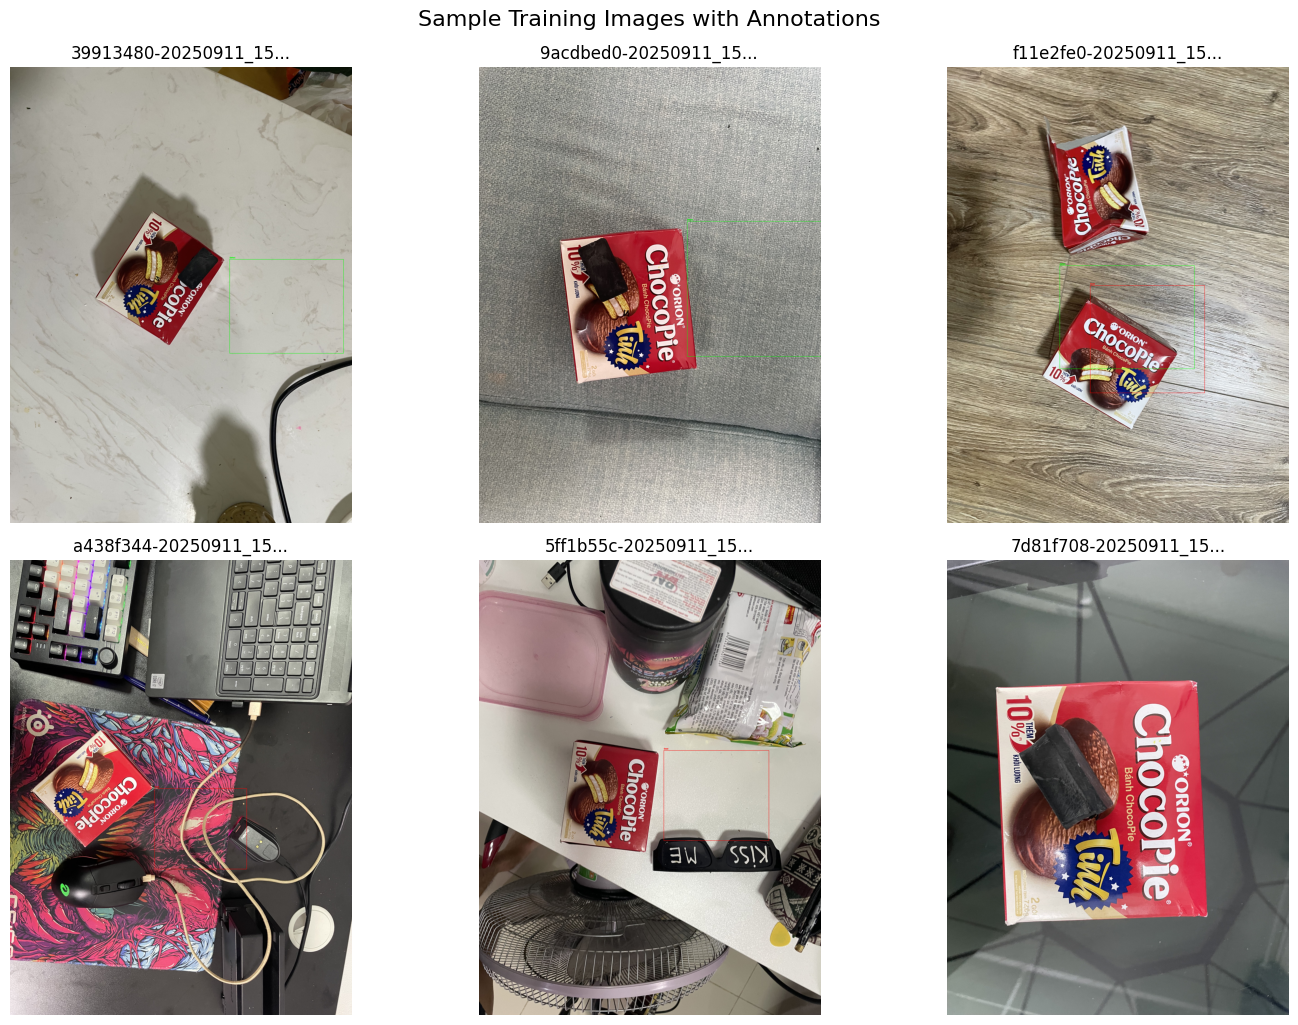

In [5]:
def visualize_sample_data(num_samples: int = 6):
    """Visualize sample images with their annotations."""
    print(f"🖼️  Visualizing {num_samples} sample images with annotations...")
    
    # Load classes
    classes = load_classes()
    
    # Get sample images from train split
    train_img_dir = os.path.join(OUTPUT_DATASET_DIR, 'images', 'train')
    train_label_dir = os.path.join(OUTPUT_DATASET_DIR, 'labels', 'train')
    
    if not os.path.exists(train_img_dir):
        print(f"❌ Train directory not found: {train_img_dir}")
        return
    
    image_files = [f for f in os.listdir(train_img_dir) 
                   if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
    
    if len(image_files) < num_samples:
        num_samples = len(image_files)
    
    # Create subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()
    
    for i in range(num_samples):
        img_file = image_files[i]
        img_path = os.path.join(train_img_dir, img_file)
        label_path = os.path.join(train_label_dir, os.path.splitext(img_file)[0] + '.txt')
        
        # Load image
        img = cv2.imread(img_path)
        if img is None:
            continue
            
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]
        
        # Load and draw annotations
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                annotations = [line.strip() for line in f if line.strip()]
            
            for annotation in annotations:
                parts = annotation.split()
                if len(parts) == 5:
                    class_id = int(parts[0])
                    x_center, y_center, width, height = [float(x) for x in parts[1:5]]
                    
                    # Convert to pixel coordinates
                    x1 = int((x_center - width/2) * w)
                    y1 = int((y_center - height/2) * h)
                    x2 = int((x_center + width/2) * w)
                    y2 = int((y_center + height/2) * h)
                    
                    # Draw bounding box
                    color = (255, 0, 0) if class_id == 1 else (0, 255, 0)  # Red for defect, green for normal
                    cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
                    
                    # Draw label
                    class_name = classes[class_id] if class_id < len(classes) else f"Class {class_id}"
                    cv2.putText(img, class_name, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
        
        # Display image
        axes[i].imshow(img)
        axes[i].set_title(f"{img_file[:20]}..." if len(img_file) > 20 else img_file)
        axes[i].axis('off')
    
    # Hide empty subplots
    for i in range(num_samples, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.suptitle('Sample Training Images with Annotations', y=1.02, fontsize=16)
    plt.show()

if dataset_valid and 'dataset_yaml' in locals():
    visualize_sample_data()

## 5. Train YOLO Model

In [6]:
def train_yolo_model(
    dataset_yaml: str,
    epochs: int = 100,
    imgsz: int = 640,
    batch: int = 16,
    model_name: str = "labelstudio_yolo_model"
) -> str:
    """Train YOLO model with Label Studio data."""
    print(f"🚀 Starting YOLO training with Label Studio data...")
    print(f"📊 Configuration:")
    print(f"   Dataset: {dataset_yaml}")
    print(f"   Epochs: {epochs}")
    print(f"   Image size: {imgsz}")
    print(f"   Batch size: {batch}")
    print(f"   Model name: {model_name}")
    
    # Initialize YOLO detector
    yolo_detector = YOLODefectDetector()
    
    # Try to load a suitable pretrained model
    pretrained_models = [
        "yolo11s.pt",     # YOLO11 small (latest)
        "yolov8s.pt",     # YOLOv8 small
        "yolov8n.pt",     # YOLOv8 nano (faster)
        "yolo11n.pt"      # YOLO11 nano
    ]
    
    model_loaded = False
    loaded_model = None
    
    for model_file in pretrained_models:
        print(f"🔄 Trying to load {model_file}...")
        if yolo_detector.load_model(model_file):
            print(f"✅ Successfully loaded model: {model_file}")
            loaded_model = model_file
            model_loaded = True
            break
        else:
            print(f"⚠️  Failed to load {model_file}, trying next...")
    
    if not model_loaded:
        print("❌ Failed to load any pretrained model")
        return None
    
    try:
        # Train the model with optimized parameters for defect detection
        print(f"📈 Training YOLO model...")
        
        best_weights = yolo_detector.train(
            dataset_yaml=dataset_yaml,
            epochs=epochs,
            imgsz=imgsz,
            batch=batch,
            project='trained_models',
            name=model_name,
            # Enhanced parameters for defect detection
            patience=50,
            save_period=10,
            # Optimized augmentation
            hsv_h=0.015,
            hsv_s=0.7,
            hsv_v=0.4,
            degrees=10.0,
            translate=0.1,
            scale=0.2,
            shear=2.0,
            flipud=0.0,
            fliplr=0.5,
            mosaic=1.0,
            mixup=0.1,
            # Training parameters
            lr0=0.01,
            lrf=0.01,
            momentum=0.937,
            weight_decay=0.0005,
            warmup_epochs=3,
            # Loss weights
            box=0.05,
            cls=0.5,
            dfl=1.5,
            close_mosaic=10
        )
        
        if best_weights:
            print(f"✅ Training completed successfully!")
            print(f"📄 Best weights saved to: {best_weights}")
            return best_weights
        else:
            print(f"❌ Training completed but no weights returned")
            return None
            
    except Exception as e:
        print(f"❌ Training failed: {str(e)}")
        print("💡 Possible solutions:")
        print("   - Reduce batch size (try batch=8 or batch=4)")
        print("   - Reduce image size (try imgsz=416 or imgsz=320)")
        print("   - Check available memory")
        print("   - Ensure dataset format is correct")
        return None

# Start training if dataset is ready
if dataset_valid and 'dataset_yaml' in locals():
    # Configure training parameters
    EPOCHS = 100  # Adjust based on your needs
    BATCH_SIZE = 16  # Reduce if you get memory errors
    IMAGE_SIZE = 640
    MODEL_NAME = "labelstudio_chocopie_detector"
    
    print(f"🎯 Starting training with Label Studio data...")
    trained_model_path = train_yolo_model(
        dataset_yaml=dataset_yaml,
        epochs=EPOCHS,
        batch=BATCH_SIZE,
        imgsz=IMAGE_SIZE,
        model_name=MODEL_NAME
    )
    
    if trained_model_path:
        print(f"🎉 Training successful! Model saved to: {trained_model_path}")
    else:
        print(f"❌ Training failed. Please check the error messages above.")
else:
    print("❌ Cannot start training - dataset preparation failed")

🎯 Starting training with Label Studio data...
🚀 Starting YOLO training with Label Studio data...
📊 Configuration:
   Dataset: training_data/labelstudio_yolo_dataset/dataset.yaml
   Epochs: 100
   Image size: 640
   Batch size: 16
   Model name: labelstudio_chocopie_detector
🔄 Trying to load yolo11s.pt...
Model loaded from yolo11s.pt
✅ Successfully loaded model: yolo11s.pt
📈 Training YOLO model...
🚀 Starting Enhanced YOLOv8 training...
   📊 Dataset: training_data/labelstudio_yolo_dataset/dataset.yaml
   🔄 Epochs: 100
   📐 Image size: 640
   📦 Batch size: 16
   🎯 Enhanced augmentation: ON
   ⚙️  Optimized for rich dataset: ON
Model loaded from yolo11s.pt
✅ Successfully loaded model: yolo11s.pt
📈 Training YOLO model...
🚀 Starting Enhanced YOLOv8 training...
   📊 Dataset: training_data/labelstudio_yolo_dataset/dataset.yaml
   🔄 Epochs: 100
   📐 Image size: 640
   📦 Batch size: 16
   🎯 Enhanced augmentation: ON
   ⚙️  Optimized for rich dataset: ON
New https://pypi.org/project/ultralytics/8

train: Scanning /mnt/mainhold/Downloads-Main/abb-capstone/training_data/labelstudio_yolo_dataset/labels/train... 60 images, 4 backgrounds, 0 corrupt: 100%|██████████| 60/60 [00:00<00:00, 4766.62it/s]

train: New cache created: /mnt/mainhold/Downloads-Main/abb-capstone/training_data/labelstudio_yolo_dataset/labels/train.cache


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 17247.5±1846.9 MB/s, size: 2169.6 KB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 17247.5±1846.9 MB/s, size: 2169.6 KB)


/home/dealoux/.cache/pypoetry/virtualenvs/abbvisionsystem-7xechF3d-py3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
val: Scanning /mnt/mainhold/Downloads-Main/abb-capstone/training_data/labelstudio_yolo_dataset/labels/val... 13 images, 1 backgrounds, 0 corrupt: 100%|██████████| 13/13 [00:00<00:00, 5993.18it/s]

...

    100/100         0G   0.006385     0.5491      1.112         17        640: 100%|██████████| 4/4 [00:11<00:00,  2.94s/it]
    100/100         0G   0.006385     0.5491      1.112         17        640: 100%|██████████| 4/4 [00:11<00:00,  2.94s/it]/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.22s/it]

                   all         13         16      0.853      0.697      0.732      0.501



100 epochs completed in 0.353 hours.
Optimizer stripped from trained_models/labelstudio_chocopie_detector/weights/last.pt, 19.2MB
Optimizer stripped from trained_models/labelstudio_chocopie_detector/weights/last.pt, 19.2MB
Optimizer stripped from trained_models/labelstudio_chocopie_detector/weights/best.pt, 19.2MB

Validating trained_models/labelstudio_chocopie_detector/weights/best.pt...
Ultralytics 8.3.141 🚀 Python-3.12.11 torch-2.7.0+cu126 CPU (AMD Ryzen 7 9700X 8-Core Processor)
Optimizer stripped from trained_models/labelstudio_chocopie_detector/weights/best.pt, 19.2MB

Validating trained_models/labelstudio_chocopie_detector/weights/best.pt...
Ultralytics 8.3.141 🚀 Python-3.12.11 torch-2.7.0+cu126 CPU (AMD Ryzen 7 9700X 8-Core Processor)
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs
YOLO11s summary (fused): 100 layers, 9,413,574 parameters, 0 gradients, 21.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.05s/it]



                   all         13         16      0.884      0.875      0.899      0.586
                Defect          4          4      0.944          1      0.995      0.633
                  Good         11         12      0.824       0.75      0.804      0.539
                Defect          4          4      0.944          1      0.995      0.633
                  Good         11         12      0.824       0.75      0.804      0.539
Speed: 0.6ms preprocess, 51.2ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to trained_models/labelstudio_chocopie_detector
Speed: 0.6ms preprocess, 51.2ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to trained_models/labelstudio_chocopie_detector
Model loaded from trained_models/labelstudio_chocopie_detector/weights/best.pt
✅ Enhanced training completed! Best weights: trained_models/labelstudio_chocopie_detector/weights/best.pt
📈 Training Summary:
   📊 Model: trained_models/labelstudio_chocopie_detector/wei

## 6. Test Model Compatibility

🧪 Testing model compatibility with existing detection system...
🔄 Loading model with YOLODefectModel...
✅ Model loaded successfully with YOLODefectModel
🖼️  Testing prediction on: 1c86b281-20250911_153407438_iOS.jpg
✅ Prediction successful!
   Detections: 2
   Classes found: {np.int64(0), np.int64(1)}
🎨 Testing visualization...
✅ Prediction successful!
   Detections: 2
   Classes found: {np.int64(0), np.int64(1)}
🎨 Testing visualization...
✅ Visualization successful!
✅ Visualization successful!


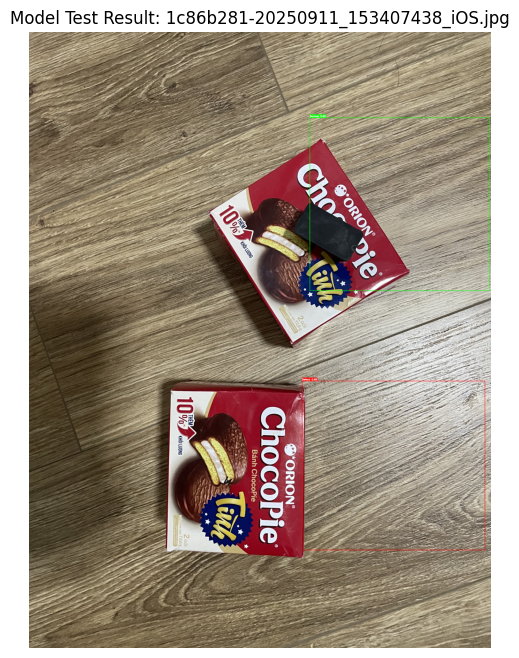

🎯 Model is fully compatible with existing detection system!

🎉 SUCCESS! Your model is ready for deployment!
📁 Model location: trained_models/labelstudio_chocopie_detector/weights/best.pt
💡 To use this model in your detection system:
   1. Update your YOLODefectModel to point to this path
   2. Or copy the model to your preferred location
   3. The model is fully compatible with your existing detection page


In [7]:
def test_model_compatibility(model_path: str):
    """Test if the trained model is compatible with the existing detection system."""
    print(f"🧪 Testing model compatibility with existing detection system...")
    
    if not os.path.exists(model_path):
        print(f"❌ Model file not found: {model_path}")
        return False
    
    try:
        # Test with existing YOLODefectModel class
        print(f"🔄 Loading model with YOLODefectModel...")
        yolo_model = YOLODefectModel(model_path)
        
        if yolo_model.load():
            print(f"✅ Model loaded successfully with YOLODefectModel")
            
            # Test with a sample image
            test_img_dir = os.path.join(OUTPUT_DATASET_DIR, 'images', 'test')
            if os.path.exists(test_img_dir):
                test_images = [f for f in os.listdir(test_img_dir) 
                              if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
                
                if test_images:
                    test_img_path = os.path.join(test_img_dir, test_images[0])
                    print(f"🖼️  Testing prediction on: {test_images[0]}")
                    
                    # Test prediction
                    result = yolo_model.predict(test_img_path)
                    
                    if result is not None:
                        print(f"✅ Prediction successful!")
                        print(f"   Detections: {result.get('num_detections', 0)}")
                        print(f"   Classes found: {set(result.get('classes', []))}")
                        
                        # Test visualization
                        print(f"🎨 Testing visualization...")
                        vis_result = yolo_model.visualize_detections(test_img_path, result)
                        
                        if vis_result is not None:
                            print(f"✅ Visualization successful!")
                            
                            # Display the result
                            plt.figure(figsize=(10, 8))
                            plt.imshow(vis_result)
                            plt.title(f"Model Test Result: {test_images[0]}")
                            plt.axis('off')
                            plt.show()
                            
                            print(f"🎯 Model is fully compatible with existing detection system!")
                            return True
                        else:
                            print(f"❌ Visualization failed")
                    else:
                        print(f"❌ Prediction failed")
                else:
                    print(f"⚠️  No test images found")
            else:
                print(f"⚠️  Test directory not found: {test_img_dir}")
        else:
            print(f"❌ Failed to load model with YOLODefectModel")
    
    except Exception as e:
        print(f"❌ Compatibility test failed: {str(e)}")
        return False
    
    return False

# Test compatibility if training was successful
if 'trained_model_path' in locals() and trained_model_path:
    compatibility_success = test_model_compatibility(trained_model_path)
    
    if compatibility_success:
        print(f"\n🎉 SUCCESS! Your model is ready for deployment!")
        print(f"📁 Model location: {trained_model_path}")
        print(f"💡 To use this model in your detection system:")
        print(f"   1. Update your YOLODefectModel to point to this path")
        print(f"   2. Or copy the model to your preferred location")
        print(f"   3. The model is fully compatible with your existing detection page")
    else:
        print(f"\n⚠️  Model trained but compatibility issues detected")
        print(f"   Please check the error messages above")
else:
    print(f"\n❌ No trained model available for compatibility testing")

## 7. Model Evaluation and Metrics

📊 Evaluating trained model...
🖼️  Testing on 14 images...

📈 Evaluation Results:
   Total images tested: 14
   Images with detections: 12
   Detection rate: 85.71%
   Total detections: 17
   Avg detections per image: 1.21
   Class distribution:
     Normal (class 0): 6
     Defect (class 1): 11
   Average confidence: 0.599

📈 Evaluation Results:
   Total images tested: 14
   Images with detections: 12
   Detection rate: 85.71%
   Total detections: 17
   Avg detections per image: 1.21
   Class distribution:
     Normal (class 0): 6
     Defect (class 1): 11
   Average confidence: 0.599


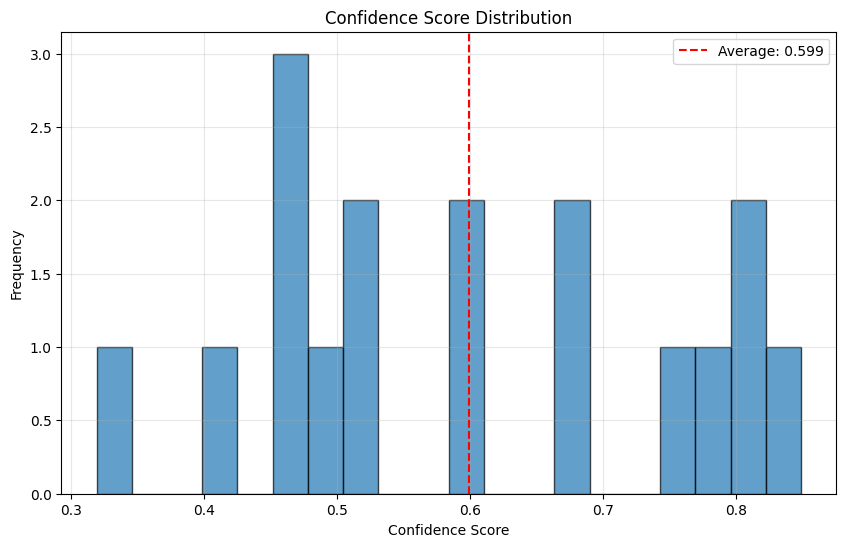

In [8]:
def evaluate_trained_model(model_path: str, test_data_dir: str):
    """Evaluate the trained model on test data."""
    print(f"📊 Evaluating trained model...")
    
    if not os.path.exists(model_path):
        print(f"❌ Model not found: {model_path}")
        return
    
    try:
        # Load model
        yolo_model = YOLODefectModel(model_path)
        if not yolo_model.load():
            print(f"❌ Failed to load model")
            return
        
        # Get test images
        test_img_dir = os.path.join(test_data_dir, 'images', 'test')
        test_label_dir = os.path.join(test_data_dir, 'labels', 'test')
        
        if not os.path.exists(test_img_dir):
            print(f"❌ Test images directory not found: {test_img_dir}")
            return
        
        test_images = [f for f in os.listdir(test_img_dir) 
                      if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))]
        
        if not test_images:
            print(f"❌ No test images found")
            return
        
        print(f"🖼️  Testing on {len(test_images)} images...")
        
        # Evaluation metrics
        total_images = 0
        images_with_detections = 0
        total_detections = 0
        class_detections = {0: 0, 1: 0}  # normal, defect
        confidence_scores = []
        
        # Process each test image
        for img_file in test_images[:20]:  # Limit to first 20 for demo
            img_path = os.path.join(test_img_dir, img_file)
            
            try:
                # Run prediction
                result = yolo_model.predict(img_path, conf_threshold=0.25)
                
                total_images += 1
                num_detections = result.get('num_detections', 0)
                
                if num_detections > 0:
                    images_with_detections += 1
                    total_detections += num_detections
                    
                    # Count class detections
                    for cls in result.get('classes', []):
                        if cls in class_detections:
                            class_detections[cls] += 1
                    
                    # Collect confidence scores
                    confidence_scores.extend(result.get('scores', []))
                
            except Exception as e:
                print(f"⚠️  Error processing {img_file}: {str(e)}")
                continue
        
        # Calculate and display metrics
        if total_images > 0:
            detection_rate = images_with_detections / total_images
            avg_detections_per_image = total_detections / total_images
            avg_confidence = np.mean(confidence_scores) if confidence_scores else 0
            
            print(f"\n📈 Evaluation Results:")
            print(f"   Total images tested: {total_images}")
            print(f"   Images with detections: {images_with_detections}")
            print(f"   Detection rate: {detection_rate:.2%}")
            print(f"   Total detections: {total_detections}")
            print(f"   Avg detections per image: {avg_detections_per_image:.2f}")
            print(f"   Class distribution:")
            print(f"     Normal (class 0): {class_detections[0]}")
            print(f"     Defect (class 1): {class_detections[1]}")
            print(f"   Average confidence: {avg_confidence:.3f}")
            
            # Plot confidence distribution
            if confidence_scores:
                plt.figure(figsize=(10, 6))
                plt.hist(confidence_scores, bins=20, alpha=0.7, edgecolor='black')
                plt.title('Confidence Score Distribution')
                plt.xlabel('Confidence Score')
                plt.ylabel('Frequency')
                plt.axvline(avg_confidence, color='red', linestyle='--', 
                           label=f'Average: {avg_confidence:.3f}')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.show()
        
    except Exception as e:
        print(f"❌ Evaluation failed: {str(e)}")

# Run evaluation if model training was successful
if 'trained_model_path' in locals() and trained_model_path:
    evaluate_trained_model(trained_model_path, OUTPUT_DATASET_DIR)

## 8. Save Model Configuration

In [9]:
def save_model_configuration(model_path: str, dataset_yaml: str):
    """Save model configuration for easy deployment."""
    print(f"💾 Saving model configuration...")
    
    if not os.path.exists(model_path):
        print(f"❌ Model not found: {model_path}")
        return
    
    # Load classes from dataset config
    classes = load_classes()
    
    # Create configuration
    config = {
        "model_info": {
            "model_path": model_path,
            "model_type": "YOLOv11/v8 Object Detection",
            "training_data": "Label Studio Annotations",
            "dataset_config": dataset_yaml,
            "classes": classes,
            "num_classes": len(classes)
        },
        "deployment": {
            "compatible_with": "YOLODefectModel class",
            "detection_page_ready": True,
            "confidence_threshold": 0.25,
            "iou_threshold": 0.45
        },
        "usage_instructions": [
            "1. Copy model to desired location",
            "2. Update YOLODefectModel model_path parameter",
            "3. Model is compatible with existing detection system",
            "4. Use confidence threshold 0.25 for best results"
        ]
    }
    
    # Save configuration
    config_path = os.path.join(os.path.dirname(model_path), 'model_config.json')
    
    try:
        with open(config_path, 'w') as f:
            json.dump(config, f, indent=2)
        
        print(f"✅ Configuration saved to: {config_path}")
        print(f"\n📋 Model Ready for Deployment:")
        print(f"   Model: {model_path}")
        print(f"   Config: {config_path}")
        print(f"   Classes: {classes}")
        print(f"   Compatible: ✅ YOLODefectModel")
        print(f"   Detection Page: ✅ Ready")
        
        return config_path
        
    except Exception as e:
        print(f"❌ Failed to save configuration: {str(e)}")
        return None

# Save configuration if training was successful
if 'trained_model_path' in locals() and trained_model_path and 'dataset_yaml' in locals():
    config_path = save_model_configuration(trained_model_path, dataset_yaml)
    
    print(f"\n🎉 TRAINING COMPLETED SUCCESSFULLY!")
    print(f"\n📦 Your trained model is ready:")
    print(f"   🎯 Model: {trained_model_path}")
    print(f"   ⚙️  Config: {config_path if config_path else 'Not saved'}")
    print(f"   ✅ Compatible with existing detection system")
    print(f"   🚀 Ready for deployment!")
    
    print(f"\n💡 Next Steps:")
    print(f"   1. Test the model on your detection page")
    print(f"   2. Adjust confidence threshold if needed (default: 0.25)")
    print(f"   3. Deploy to production when satisfied with results")
else:
    print(f"\n❌ Training not completed successfully")
    print(f"   Please review the error messages above and retry")

💾 Saving model configuration...
✅ Loaded 2 classes: ['Defect', 'Good']
✅ Configuration saved to: trained_models/labelstudio_chocopie_detector/weights/model_config.json

📋 Model Ready for Deployment:
   Model: trained_models/labelstudio_chocopie_detector/weights/best.pt
   Config: trained_models/labelstudio_chocopie_detector/weights/model_config.json
   Classes: ['Defect', 'Good']
   Compatible: ✅ YOLODefectModel
   Detection Page: ✅ Ready

🎉 TRAINING COMPLETED SUCCESSFULLY!

📦 Your trained model is ready:
   🎯 Model: trained_models/labelstudio_chocopie_detector/weights/best.pt
   ⚙️  Config: trained_models/labelstudio_chocopie_detector/weights/model_config.json
   ✅ Compatible with existing detection system
   🚀 Ready for deployment!

💡 Next Steps:
   1. Test the model on your detection page
   2. Adjust confidence threshold if needed (default: 0.25)
   3. Deploy to production when satisfied with results
